# Advanced Analytics - Day 6

This notebook covers VaR/CVaR, rolling Sharpe, cohort analysis, SIP continuity, a simple recommender and sector concentration risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

raw = Path('../data/raw')
processed = Path('../data/processed')
charts = Path('../reports/charts')
charts.mkdir(parents=True, exist_ok=True)

## 1. Historical VaR and CVaR

VaR is calculated using the 5th percentile of daily returns. CVaR is the average return below that VaR threshold.

In [2]:
nav = pd.read_csv(raw / '02_nav_history.csv')
fund_master = pd.read_csv(raw / '01_fund_master.csv')
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

var_rows = []
for code, group in nav.dropna(subset=['daily_return']).groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_rows.append([code, var_95, cvar_95, returns.mean(), returns.std(), len(returns)])

var_cvar = pd.DataFrame(var_rows, columns=['amfi_code','var_95_daily','cvar_95_daily','avg_daily_return','daily_volatility','observations'])
var_cvar = var_cvar.merge(fund_master[['amfi_code','scheme_name','fund_house','category','sub_category','risk_category']], on='amfi_code', how='left')
var_cvar.to_csv(processed / 'var_cvar_report.csv', index=False)
var_cvar.sort_values('var_95_daily').head()

,amfi_code,var_95_daily,cvar_95_daily,avg_daily_return,daily_volatility,observations,scheme_name,fund_house,category,sub_category,risk_category
22,119599,-0.026859,-0.032384,0.000201,0.015717,1149,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Very High
17,119095,-0.026188,-0.031667,0.000182,0.015790,1149,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Small Cap,Very High
4,101207,-0.026021,-0.032459,0.000424,0.016251,1149,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,Very High
11,118634,-0.025438,-0.032304,0.000707,0.015901,1149,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Small Cap,Very High
21,119598,-0.024507,-0.030595,0.001201,0.015837,1149,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Very High


## 2. Rolling 90-day Sharpe Ratio

The rolling Sharpe helps check how risk-adjusted returns changed over time instead of relying only on one final number.

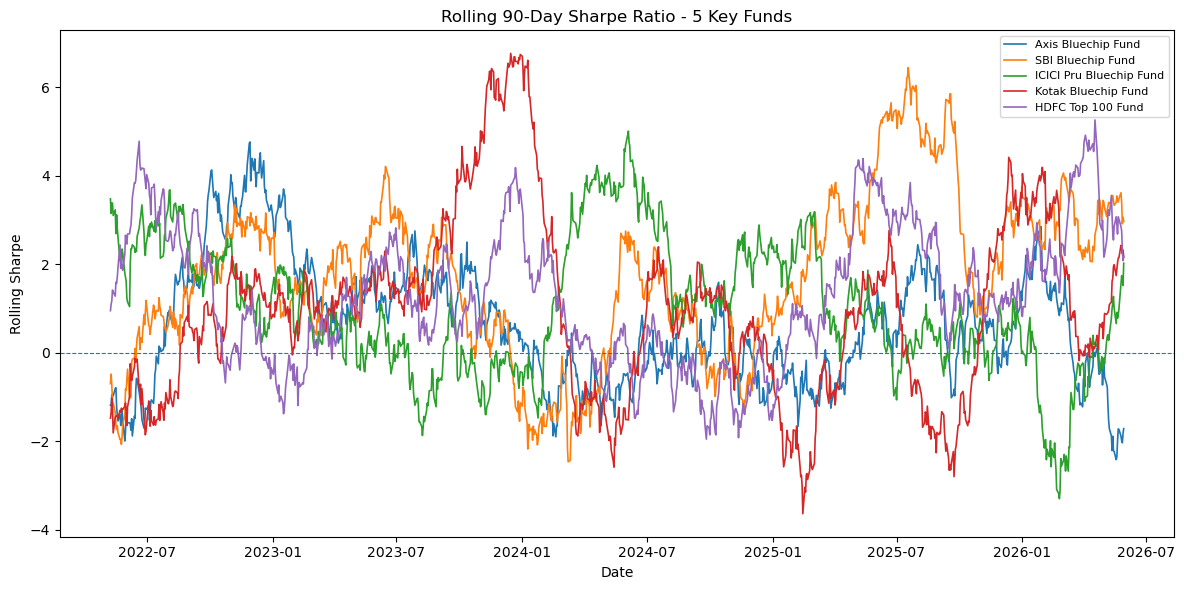

In [3]:
key_codes = [119551, 125497, 120503, 119092, 120841]
roll = nav[nav['amfi_code'].isin(key_codes)].copy()
roll['rolling_sharpe_90d'] = roll.groupby('amfi_code')['daily_return'].transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
roll = roll.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code', how='left')

plt.figure(figsize=(12,6))
for code, group in roll.groupby('amfi_code'):
    plt.plot(group['date'], group['rolling_sharpe_90d'], label=group['scheme_name'].iloc[0].split(' - ')[0], linewidth=1.2)
plt.axhline(0, linestyle='--', linewidth=0.8)
plt.title('Rolling 90-Day Sharpe Ratio - 5 Key Funds')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(charts / 'rolling_sharpe_chart.png', dpi=160)
plt.show()

## 3. Investor Cohort Analysis

In [4]:
transactions = pd.read_csv(raw / '08_investor_transactions.csv')
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
transactions['transaction_type'] = transactions['transaction_type'].str.strip().str.title().replace({'Sip':'SIP'})
first_year = transactions.groupby('investor_id')['transaction_date'].min().dt.year.rename('first_transaction_year')
transactions = transactions.merge(first_year, on='investor_id')

sip_tx = transactions[transactions['transaction_type'].eq('SIP')]
cohort = transactions.groupby('first_transaction_year').agg(total_invested_inr=('amount_inr','sum'), unique_investors=('investor_id','nunique'), total_transactions=('investor_id','count')).reset_index()
avg_sip = sip_tx.groupby('first_transaction_year')['amount_inr'].mean().rename('avg_sip_amount_inr').reset_index()
cohort = cohort.merge(avg_sip, on='first_transaction_year', how='left')
cohort.to_csv(processed / 'cohort_analysis.csv', index=False)
cohort

,first_transaction_year,total_invested_inr,unique_investors,total_transactions,avg_sip_amount_inr
0,2024,3491125187,4803,32499,10996.885825
1,2025,30455243,197,279,13505.209581


## 4. SIP Continuity Analysis

In [5]:
sip_sorted = sip_tx.sort_values(['investor_id','transaction_date']).copy()
sip_sorted['gap_days'] = sip_sorted.groupby('investor_id')['transaction_date'].diff().dt.days
sip_continuity = sip_sorted.groupby('investor_id').agg(sip_transactions=('transaction_date','count'), first_sip_date=('transaction_date','min'), last_sip_date=('transaction_date','max'), avg_gap_days=('gap_days','mean'), max_gap_days=('gap_days','max'), total_sip_amount=('amount_inr','sum')).reset_index()
sip_continuity = sip_continuity[sip_continuity['sip_transactions'] >= 6].copy()
sip_continuity['continuity_status'] = np.where(sip_continuity['avg_gap_days'] > 35, 'at-risk', 'regular')
sip_continuity.to_csv(processed / 'sip_continuity.csv', index=False)
sip_continuity['continuity_status'].value_counts(normalize=True)

continuity_status
at-risk    0.977974
regular    0.022026
Name: proportion, dtype: float64

## 5. Simple Fund Recommender

In [6]:
performance = pd.read_csv(raw / '07_scheme_performance.csv')

def recommend_funds(risk_appetite='Moderate', top_n=3):
    risk_col = 'risk_grade' if 'risk_grade' in performance.columns else 'risk_category'
    temp = performance[performance[risk_col].astype(str).str.title() == risk_appetite.title()].copy()
    return temp.sort_values('sharpe_ratio', ascending=False)[['scheme_name','fund_house',risk_col,'return_3yr_pct','sharpe_ratio','expense_ratio_pct']].head(top_n)

recommend_funds('Moderate')

,scheme_name,fund_house,risk_grade,return_3yr_pct,sharpe_ratio,expense_ratio_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,14.84,1.06,1.55
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,14.81,1.06,1.46
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,14.41,1.03,0.80


## 6. Sector Concentration using HHI

In [7]:
holdings = pd.read_csv(raw / '09_portfolio_holdings.csv')
holdings['weight_share'] = holdings['weight_pct'] / 100
sector_hhi = holdings.groupby('amfi_code').agg(sector_hhi=('weight_share', lambda x: np.sum(np.square(x))), number_of_holdings=('stock_symbol','count'), top_sector_weight_pct=('weight_pct','max')).reset_index()
sector_hhi = sector_hhi.merge(fund_master[['amfi_code','scheme_name','fund_house','category','sub_category']], on='amfi_code', how='left')
sector_hhi.to_csv(processed / 'sector_hhi.csv', index=False)
sector_hhi.sort_values('sector_hhi', ascending=False).head()

,amfi_code,sector_hhi,number_of_holdings,top_sector_weight_pct,scheme_name,fund_house,category,sub_category
11,119092,0.206448,10,38.18,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,Large Cap
3,101207,0.200700,8,35.07,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap
18,119599,0.174751,8,28.25,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap
4,102885,0.174709,9,28.95,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,Index
7,118632,0.168298,8,30.44,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Large Cap


## 7. Key Advanced Insights

1. SBI Small Cap Fund - Direct Plan - Growth showed the sharpest 95% daily VaR in this sample, so it needs closer downside-risk monitoring.
2. ABSL Small Cap Fund - Regular - Growth had the weakest CVaR reading, meaning its worst-return tail was more severe than most peers.
3. The 2024 investor cohort contributed the highest total transaction value in the data.
4. Among investors with 6 or more SIP transactions, around 97.8% were flagged as at-risk based on average SIP gaps above 35 days.
5. Axis Bluechip Fund - Regular - Growth had the highest sector HHI, indicating a relatively concentrated portfolio compared with other equity funds.